# In-Class Assignment: 2DFFT in image analysis
<img src="https://lh3.googleusercontent.com/BeDhQcIlYtyGLwB_XtfXd2PyWrdDvv2--zLdfd5gzyO7mHSyAj1JoAo4SB8urtnq5p2nSEbDWA=w630" width="40%">

### Agenda for today's class (110 minutes)

1. [Two dimensional FFT](#Two-dimensional-FFT)
2. [Frequency Filtering using 2D FFTs](#Frequency-Filtering-using-2D-FFTs)
3. [FFT Feature Extraction](#FFT-Feature-Extraction)



---
<a name=Two-dimensional-FFT></a>
# 1. Two dimensional FFT


In the previous class we converted a 1D time signal into it's frequency space.  In this lesson we will look at what it means to look at 2D data in the 2D frequency space. 

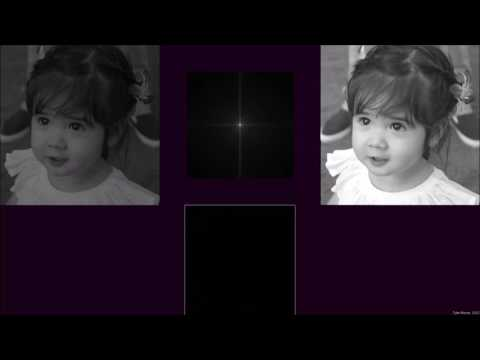

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("js4bLBYtJwY",width=640,height=360)

&#9989; **<font color=red>Question 1:</font>** In the video, please describe in your own works what is "k-space."

Put your answer to the above question here.

Now, let's write some code to practice 2D FFT as in the vidoe.

&#9989; **<font color=red>A:</font>** Go to the link below. Investigate how to read image to an array using Python. The image file in this assignment is "brick_texture3420.jpg". Find the size (shape) of the array. Imshow the image. You can google imread( ) and imshow( ) functions. **

https://docs.scipy.org/doc/scipy-0.19.1/reference/generated/scipy.misc.imread.html

Image shape: (242, 400, 3)


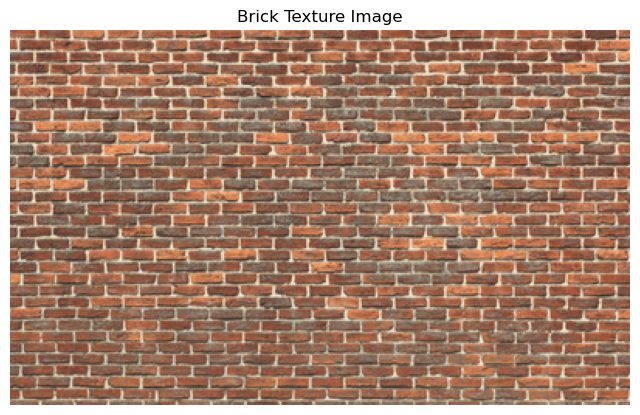

In [4]:

# Question A: Read the image, find its shape, and display it

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from urllib.request import urlretrieve
from pathlib import Path

url = 'https://gitlab.msu.edu/CMSE/CMSE202-S17-Assignments/-/raw/4c6e780ea4a3fdf3123c72a27da9d1315b20dcf0/images/fft/brick_texture3420.jpg'

filename = 'brick_texture3420.jpg'

# Download the image if it is not already saved
if not Path(filename).exists():
    urlretrieve(url, filename)

# Read the image
img = imageio.imread(filename)

# Print the image shape
print("Image shape:", np.shape(img))

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("Brick Texture Image")
plt.axis("off")
plt.show()


---
&#9989; **<font color=red>B:</font>**  An image is an array of pixels. For a color image, the array usually contains three layers of 2D pixel array. For example, Img[ 0:vert, 0:horiz, 0] is the intensity of red color of this image. The indices, vert and horiz, are the numbers of pixels along the vertical and horizontal directions of the image. Similarly, Img[ 0:vert, 0:horiz, 1] is the intensity of Green color. Img[ 0:vert, 0:horiz, 2] is the intensity of Blue color. The three values at each pixel are the intensity for Red, Green, and Blue colors for the color image.  

Now, let's convert the RGB intensity to gray scale (luminace). We can assume grey_scale = 0.2125$\times$R + 0.7154$\times$G + 0.0721$\times$B. Calculate the gray_scale intensity of the image. Imshow the gray_scale image with cmap = 'gray'. ** 

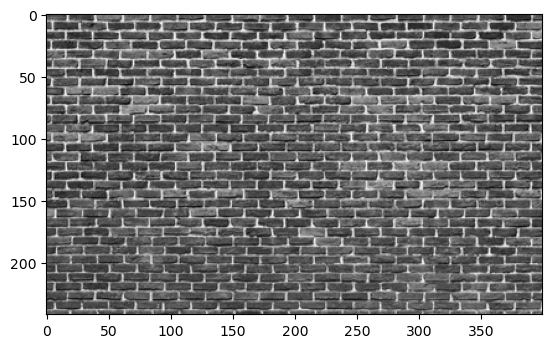

In [6]:
# Your code:

Gs_Img = (img[:,:,0]*0.2125 + img[:,:,1]*0.7154 + img[:,:,2]*0.0721)/255

plt.imshow(Gs_Img, cmap='gray')
plt.show()

---
&#9989; **<font color=red>C:</font>** Take a 2D Fast Fourier Transform of the gray-scale image.  

https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.fft.fft2.html

**Calculate the amplitude of the fft 2D array. You can use np.abs( ) calucalte the amplitude, which calculates the absolute values (amplitudes) of complex numbers. Plot the amplitude. To highlight the vairation in the amplitude, plot log10 of the amplitude.  ** 

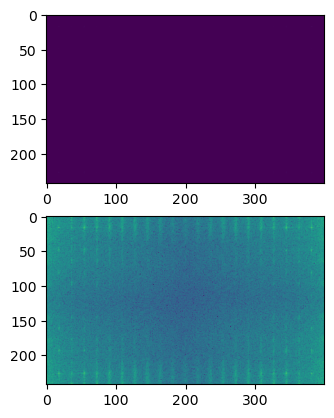

In [7]:
# Your code:

Fs = np.fft.fft2(Gs_Img)

Amp = np.abs(Fs)

lgA = np.log10(Amp)

plt.subplot(2,1,1)
plt.imshow(Amp)

plt.subplot(2,1,2)
plt.imshow(lgA)


plt.show()

---
&#9989; **<font color=red>D:</font>**  Your plot of log10 of amplitude should look different from the one in the video. You may notice that the amplitdue in the center of the plot is low, while some spots appearing near the edges of the 2D domain. This is because the fft2 function calculates the Fourtier transformation in the period from 0 to 2 $\pi$. For plots in the k space, we need to use transformation calculated in the period from $-\pi$ to $\pi$. Such that, the origin in the k space is at the center of the plot.

To do this, we need to move around the result from fft2( ) as the following. Move the upper left quarter to the lower right. The lower right to upper left. See regions A and D swapped.  Do the swap between C and D as illustrated below.

242 400


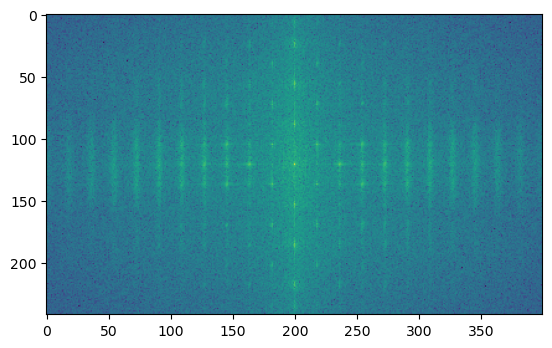

In [8]:
# Your code:

Sz_F = np.shape(lgA)
print(Sz_F[0],Sz_F[1])


nA = np.ndarray(shape = Sz_F)
nA[:int(Sz_F[0]/2),:int(Sz_F[1]/2)] = lgA[int(Sz_F[0]/2):,int(Sz_F[1]/2):]
nA[int(Sz_F[0]/2):,:int(Sz_F[1]/2)] = lgA[:int(Sz_F[0]/2),int(Sz_F[1]/2):]
nA[:int(Sz_F[0]/2),int(Sz_F[1]/2):] = lgA[int(Sz_F[0]/2):,:int(Sz_F[1]/2)]
nA[int(Sz_F[0]/2):,int(Sz_F[1]/2):] = lgA[:int(Sz_F[0]/2),:int(Sz_F[1]/2)]


plt.imshow(nA)
plt.show()

---
&#9989; **<font color=red>E:</font>** Here, let's compare our result to that from Python built-in function of fftshift. Use the function np.fft.fftshift( ) to the shift. Plot the result and compare it to the one obtained in the cell above. 


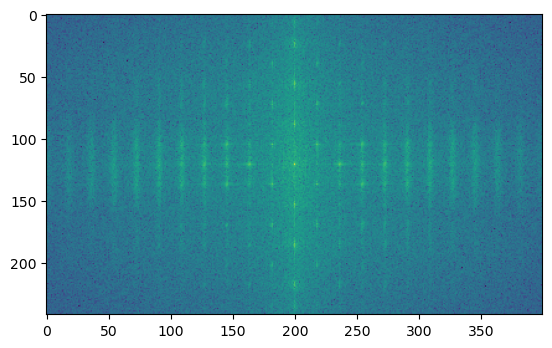

In [9]:
nB = np.fft.fftshift(lgA)

plt.imshow(nB)
plt.show()

---
&#9989; **<font color=red>Question: </font>** Note the regular pattern in the frequency space.  Where does the regular spots come from? 

Put your answer to the above question here.

----

<a name=Frequency-Filtering-using-2D-FFTs></a>
# 2. Frequency Filtering using 2D FFTs


The Frequency Space is often used to filter out periodic noise.  In this exercise you will build masks in the Frequency space to best remove the noise. 

**&#9989; DO THIS:** Run the following code and find the best mask to filter out the periodic noise in the pompeii image and the Moon landing image. 

In [10]:
#The following code snip-it downloads a file from internet and saves it to your local directory.
from urllib.request import urlopen, urlretrieve

url = 'https://goo.gl/1B2YTi'
file1 = 'moonlanding.png'
urlretrieve(url, file1);

In [11]:
#The following code snip-it downloads a file from internet and saves it to your local directory.
from urllib.request import urlopen, urlretrieve

url = 'https://goo.gl/NpqeF6'
file2 = 'pompeii_periodic_noise.png'
urlretrieve(url, file2);

In [12]:
file = file2

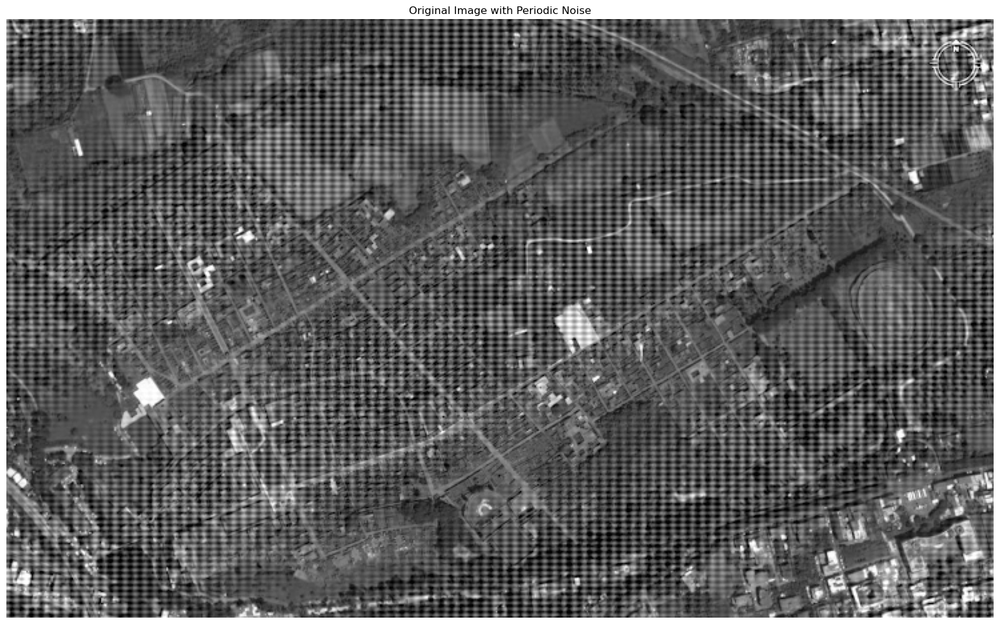

Image shape: (449, 740)


In [14]:

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import imageio.v2 as imageio

# Load the image selected in the previous cell
im = imageio.imread(file)

# Display the noisy image
plt.figure(figsize=(20, 15))
plt.imshow(im, cmap='gray')
plt.title("Original Image with Periodic Noise")
plt.axis('off')
plt.show()

print("Image shape:", im.shape)


In [18]:

# Convert color image to grayscale
import skimage.color as color

if im.ndim == 2:
    gray = im.astype(float)
elif im.shape[-1] == 3:
    gray = color.rgb2gray(im)
elif im.shape[-1] == 4:
    gray = color.rgb2gray(color.rgba2rgb(im))
else:
    raise ValueError(f"Unsupported image shape: {im.shape}")


In [21]:

# Updated 2D FFT explorer with circular mask

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interactive, fixed
from skimage.draw import disk

def filter_fft(gray, sz=0.1, flipMask=True):
    f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(20, 5))

    ax0.imshow(gray, cmap='gray')
    ax0.axis('equal')
    ax0.axis('off')
    ax0.set_title("Original Image")

    rows, cols = gray.shape

    # Generate circular mask
    if flipMask:
        mask = np.zeros((rows, cols))
        val = 1
    else:
        mask = np.ones((rows, cols))
        val = 0

    cenx = cols // 2
    ceny = rows // 2

    maxr = np.sqrt(cenx**2 + ceny**2)
    radius = maxr * sz

    # Use disk instead of deprecated circle
    rr, cc = disk((ceny, cenx), radius, shape=(rows, cols))
    mask[rr, cc] = val

    # Take 2D FFT
    Fs = np.fft.fft2(gray)

    # Shift frequencies to center
    F2 = np.fft.fftshift(Fs)

    # Apply circular mask
    F3 = F2 * mask

    # Display frequency spectrum
    psd2D = np.abs(F3)**2
    psd2D[psd2D == 0] = np.nan

    ax1.imshow(np.log10(psd2D), cmap='jet')
    ax1.axis('equal')
    ax1.axis('off')
    ax1.set_title("Frequency Spectrum")

    # Inverse FFT
    F4 = np.fft.ifftshift(F3)
    im2 = np.abs(np.fft.ifft2(F4))

    ax2.imshow(im2, cmap='gray')
    ax2.axis('equal')
    ax2.axis('off')
    ax2.set_title("Filtered Image")

    plt.tight_layout()
    plt.show()

    return im2

fft_widget = interactive(
    filter_fft,
    gray=fixed(gray),
    sz=(0, 1, 0.025),
    flipMask=True
)

display(fft_widget)


interactive(children=(FloatSlider(value=0.1, description='sz', max=1.0, step=0.025), Checkbox(value=True, desc…

Once you are happy with the above settings you can zooming on the result using the following code snip-it:

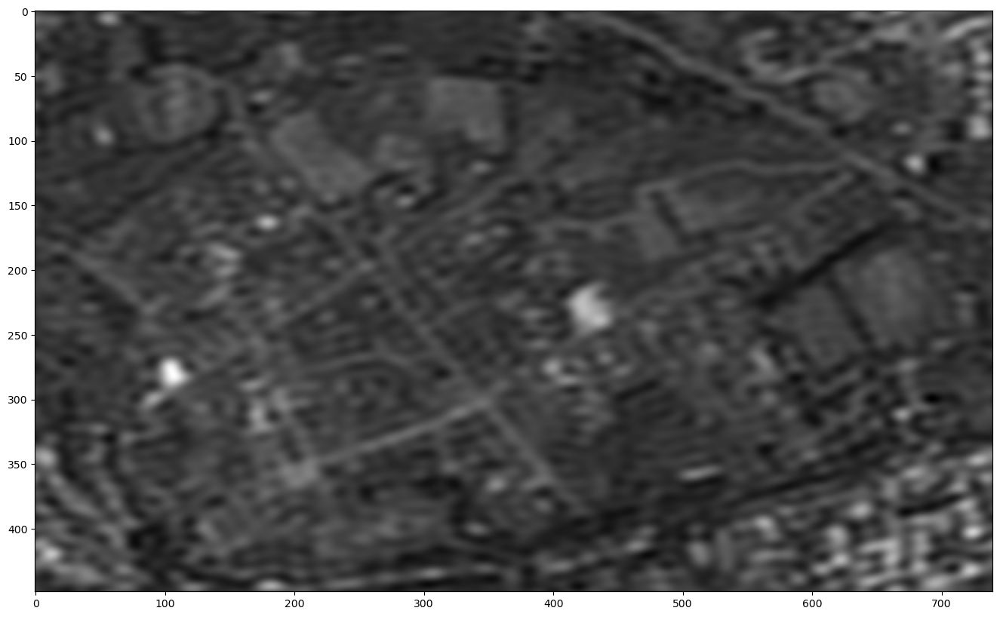

In [22]:
# Zoom in on the results of the fft_widget 
from IPython.display import clear_output

#Pull variables out of python widget
sz = fft_widget.children[0].value
flipMask = fft_widget.children[1].value

#Rerun the fft filter
im2 = filter_fft(gray, sz, flipMask)
clear_output()

#Display the results
plt.figure(figsize=(20,10))
plt.imshow(im2,cmap='gray')


#9989; **<font color=red>DO THIS: </font>** Lets do this exersize again but use a slightly more flexible tool.  Upload one of the images to ```ImageJ``` (```Fiji```) and see if you can do a better job filtering out the noise.

#9989; **<font color=red>DO THIS: </font>** Share your best results with the class. 



---
<a name=FFT-Feature-Extraction></a>
# 3. FFT Feature Extraction

As we discussed in our papers on Friday and Monday, the FFT space can be used to generate features about an image or an image itself.  In this exercise we are going to discuss an example of using FFT space to classify Car Tire Treads:

**Problem Statement:** In the US car tread patterns are copyrighted instead of being patented. This means that when tire manufacturers design a new tire they need to check the tread to ensure it does not look like a similar tread already in existence. We are going to extract features form the Fourier space that were used to build a classifier to find the closest tires to an image.


<table>
<tr height=200px>
<td><img src="http://www.biologyjunction.com/images/BridgeCoupe.jpg"> </td>
<td><img src="http://www.biologyjunction.com/images/BridgeHatch.jpg"></td>
<td><img src="http://www.biologyjunction.com/images/BridgeLux.jpg"></td>
<td><img src="http://www.biologyjunction.com/images/BridgeSUV.jpg"></td>
<td><img src="http://www.biologyjunction.com/images/BridgeSedan.jpg"></td>
<td><img src="http://www.biologyjunction.com/images/BridgeTruck.jpg"></td>
</tr>
</table>



In [58]:
#Download a Tire Database
from urllib.request import urlopen, urlretrieve
import requests
url = 'http://www.biologyjunction.com/images/'

names = ['BridgeCoupe.jpg', 'BridgeHatch.jpg', 'BridgeLux.jpg', 'BridgeSUV.jpg', 'BridgeSedan.jpg', 'BridgeTruck.jpg']

for name in names:
    fullurl = url+name;
    print(fullurl)
    r = requests.get(fullurl)
    with open(name, 'wb') as outfile:
        outfile.write(r.content)

http://www.biologyjunction.com/images/BridgeCoupe.jpg
http://www.biologyjunction.com/images/BridgeHatch.jpg
http://www.biologyjunction.com/images/BridgeLux.jpg
http://www.biologyjunction.com/images/BridgeSUV.jpg
http://www.biologyjunction.com/images/BridgeSedan.jpg
http://www.biologyjunction.com/images/BridgeTruck.jpg


In [59]:
#Polar Histogram of the FFT Space
def phist(gray):
    '''Polar fft Histogram - Calculate sub of power over all angles and radii. '''
    f = plt.figure(figsize=(20,5))

    #Plot original Image
    ax0 = f.add_subplot(141)
    ax0.imshow(gray,cmap='gray')
    ax0.axis('equal')
    ax0.axis('off')

    # Take to 2D FFT
    Fs = np.fft.fft2(gray)

    # Shift the 2D FFT into the "Standard" view
    F2 = np.fft.fftshift( Fs ) 

    # Generate easy-to-see plot
    psd2D = np.rot90(np.abs(F2)**2)
    psd2D[psd2D == 0] = np.nan
    fft = np.log10(psd2D)
    
    ax1 = f.add_subplot(142)
    ax1.imshow( fft, cmap='jet')
    ax1.axis('equal')
    ax1.axis('off')
    
    # Calculate angles
    rows = gray.shape[0]; ceny = int(rows/2)
    cols = gray.shape[1]; cenx = int(cols/2)
    dx = np.arange(cols) - cenx
    dy = np.arange(rows) - ceny
    X,Y = np.meshgrid(dy, dx)
    
    angle = np.arange(-np.pi, np.pi, (2*np.pi)/360)
    angles = np.floor(np.arctan2(Y,X)/(2*np.pi)*360)
    
    bins = np.zeros(360)

    for i in range(len(bins)):
        bins[i] = np.sum(fft[angles==(i-180)])/np.sum(angles==(i-180))
    ax2 = f.add_subplot(143, projection='polar')
    ax2.plot(angle, bins)
    ax2.set_title('FFT Power Vs Angle')
    #ax2.set_axis('polar')
    
        
    radii = X*X+Y*Y
    max_R = np.max(radii)
    n_bins = 100
    radii = np.floor(radii / max_R * n_bins)
    
    radius = np.zeros(n_bins)

    for i in range(len(radius)):
        radius[i] = np.sum(fft[radii==i])/np.sum(angles==i)
    ax2 = f.add_subplot(144)
    ax2.plot(radius)
    ax2.set_xlabel('FFT Radius')
    ax2.set_ylabel('Power')
    
    plt.show()
    return bins/np.max(bins), radius/np.max(radius)


In [60]:
tires = []
polar_bins = []
radial_bins = []

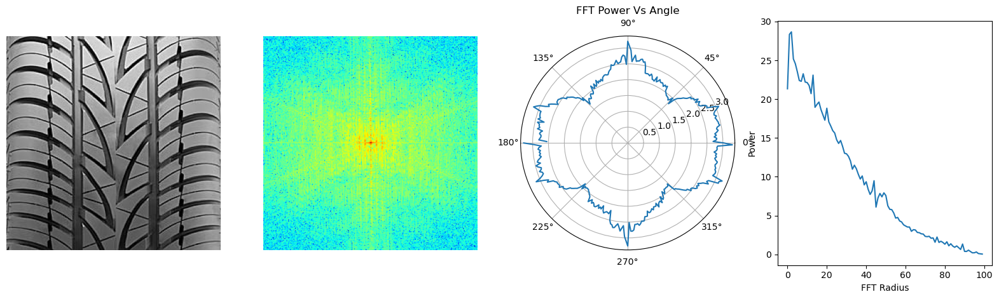

In [65]:

import imageio.v2 as imageio
from skimage import color

im = imageio.imread(names[0])

# Convert to grayscale
if im.ndim == 2:
    gray = im.astype(float)
elif im.shape[-1] == 4:
    gray = color.rgb2gray(color.rgba2rgb(im))
else:
    gray = color.rgb2gray(im)

# Calculate FFT histogram
bins, radii = phist(gray)

# Store results
tires.append(im)
polar_bins.append(bins)
radial_bins.append(radii)


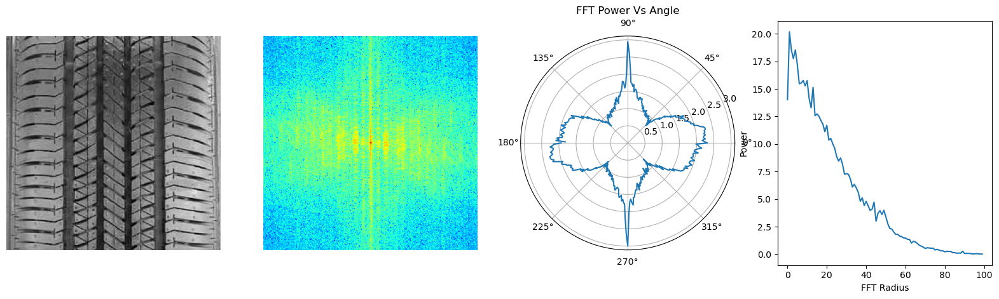

In [67]:
im = imageio.imread(names[1])

if im.ndim == 2:
    gray = im.astype(float)
elif im.shape[-1] == 4:
    gray = color.rgb2gray(color.rgba2rgb(im))
else:
    gray = color.rgb2gray(im)

bins, radii = phist(gray)

tires.append(im)
polar_bins.append(bins)
radial_bins.append(radii)

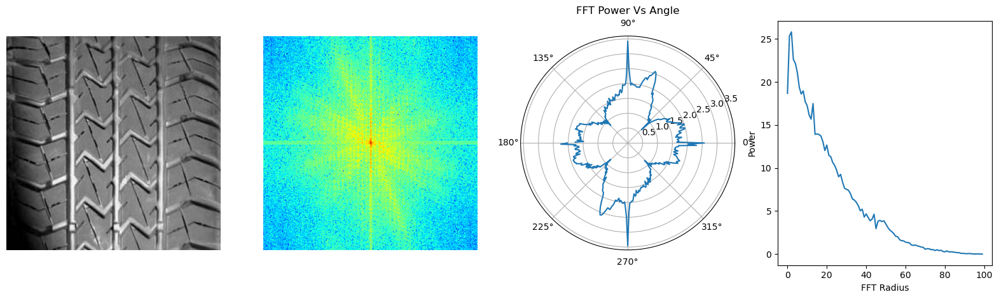

In [68]:
im = imageio.imread(names[2])

if im.ndim == 2:
    gray = im.astype(float)
elif im.shape[-1] == 4:
    gray = color.rgb2gray(color.rgba2rgb(im))
else:
    gray = color.rgb2gray(im)

bins, radii = phist(gray)

tires.append(im)
polar_bins.append(bins)
radial_bins.append(radii)

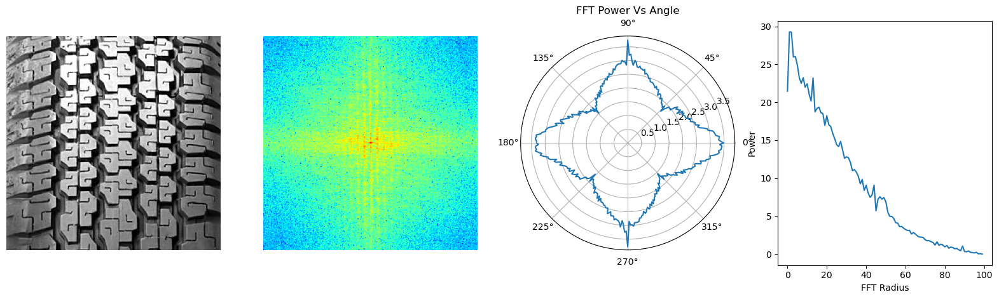

In [69]:
im = imageio.imread(names[3])

if im.ndim == 2:
    gray = im.astype(float)
elif im.shape[-1] == 4:
    gray = color.rgb2gray(color.rgba2rgb(im))
else:
    gray = color.rgb2gray(im)

bins, radii = phist(gray)

tires.append(im)
polar_bins.append(bins)
radial_bins.append(radii)

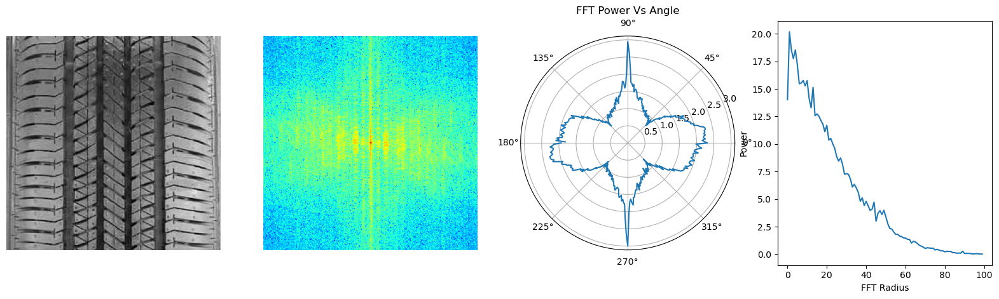

In [70]:
from PIL import Image
import numpy as np
from skimage import color

im = np.array(Image.open(names[1]).convert("RGB"))
gray = color.rgb2gray(im)
bins, radii = phist(gray)

tires.append(im)
polar_bins.append(bins)
radial_bins.append(radii)

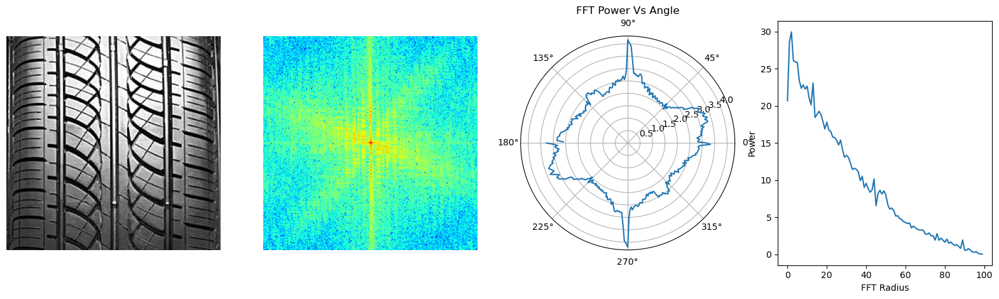

In [72]:
im = imageio.imread(names[4])

if im.ndim == 2:
    gray = im.astype(float)
elif im.shape[-1] == 4:
    gray = color.rgb2gray(color.rgba2rgb(im))
else:
    gray = color.rgb2gray(im)

bins, radii = phist(gray)

tires.append(im)
polar_bins.append(bins)
radial_bins.append(radii)

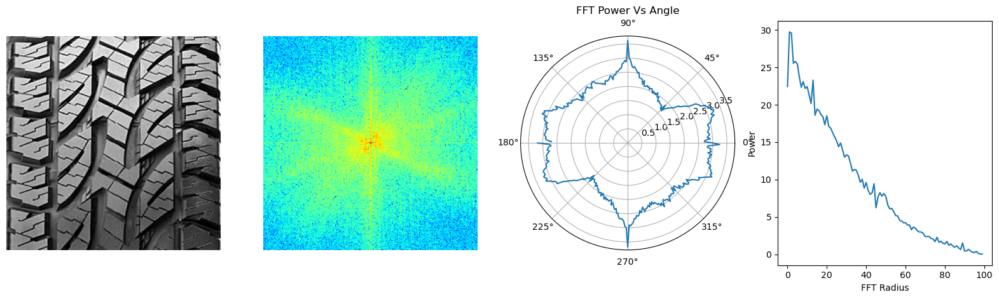

In [75]:
im = imageio.imread(names[5])

if im.ndim == 2:
    gray = im.astype(float)
elif im.shape[-1] == 4:
    gray = color.rgb2gray(color.rgba2rgb(im))
else:
    gray = color.rgb2gray(im)

bins, radii = phist(gray)

tires.append(im)
polar_bins.append(bins)
radial_bins.append(radii)

Simple distance Comparison. Here are the pictures again.

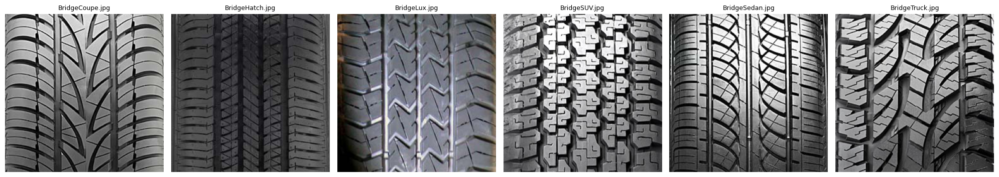

In [77]:
n = min(len(names), len(tires))

f, axes = plt.subplots(1, n, figsize=(20, 5))

for i in range(n):
    axes[i].imshow(tires[i], cmap='gray')
    axes[i].set_title(names[i], fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

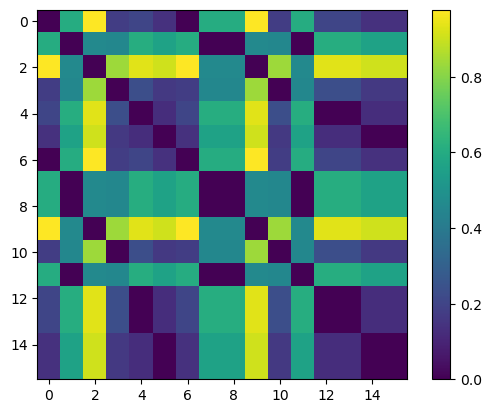

In [78]:
#Measure distance between all vectors 

# Try both polar_bins and radial_bins

from sklearn.metrics import pairwise

x = pairwise.pairwise_distances(radial_bins)

tires.append(im)
plt.imshow(x)
plt.colorbar()

&#9989; **<font color=red>DO THIS: </font>** Discuss this matrix in class.

---

Written by Dr. Dirk Colbry, Michigan State University
<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

---